In [27]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# import t-SNE
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


class CHIMEFRBDataset(Dataset):
    def __init__(self, hdf5_path, catalog_path, target_length):
        self.hdf5_path = hdf5_path
        self.dt = 0.009830400085775182 * 1000
        self._h5 = None

        self.target_length = target_length
        cat = pd.read_csv(catalog_path, low_memory=False)
        cat["repeater_name"] = cat["repeater_name"].fillna("").str.strip()
        self.repeater_set = set(
            cat.loc[cat["repeater_name"] != "", "tns_name"].str.strip()
        )
        with h5py.File(hdf5_path, "r") as f:
            self.keys = list(f.keys())
        self.labels = np.array([int(k in self.repeater_set) for k in self.keys], dtype=np.int64)

    @staticmethod
    def _pad_or_crop(wfall, target_length, center_idx):
        n_freq, n_time = wfall.shape
        half = target_length // 2
        start = center_idx - half
        end = start + target_length

        if start >= 0 and end <= n_time:
            return wfall[:, start:end]

        src_start = max(start, 0)
        src_end = min(end, n_time)
        out = np.zeros((n_freq, target_length), dtype=wfall.dtype)
        dst_start = src_start - start
        out[:, dst_start:dst_start + (src_end - src_start)] = wfall[:, src_start:src_end]
        return out

    def _get_file(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.hdf5_path, "r")
        return self._h5

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]

        f = self._get_file()
        wfall = f[key]["wfall_plot"][:]
        extent = np.array(f[key]["extent"])

        wfall = wfall.astype(np.float32)
        std = wfall.std(axis=1, keepdims=True)
        std[std == 0] = 1.0  # avoid divide-by-zero for masked channels
        wfall = (wfall - wfall.mean(axis=1, keepdims=True)) / std

        peak = round(-extent[0] / self.dt)
        wfall = self._pad_or_crop(wfall, self.target_length, peak)
        tensor = torch.from_numpy(wfall)
        label = torch.tensor(int(key in self.repeater_set), dtype=torch.long)

        return tensor, label


TARGET_LENGTH = 128
N_SPLITS = 5
BATCH_SIZE = 64
NUM_WORKERS = 5
SEED = 42



class SupConLoss(nn.Module):

    def __init__(self, temperature=0.07, contrast_mode="all", base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):

        if len(features.shape) < 3:
            raise ValueError("`features` needs to be [bsz, n_views, ...]," "at least 3 dimensions are required")
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError("Cannot define both `labels` and `mask`")
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError("Num of labels does not match num of features")
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == "one":
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == "all":
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError("Unknown mode: {}".format(self.contrast_mode))

        anchor_dot_contrast = torch.div(torch.matmul(anchor_feature, contrast_feature.T), self.temperature)
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        mask = mask.repeat(anchor_count, contrast_count)
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(batch_size * anchor_count).view(-1, 1).to(device), 0)
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 1, mask_pos_pairs)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss


class FocalLoss(nn.Module):
    def __init__(self, gamma=0.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.eps = 1e-6

    def forward(self, logits, labels):
        p = torch.sigmoid(logits)
        p_t = p * labels + (1 - p) * (1 - labels)
        p_t = p_t.clamp(min=self.eps, max=1 - self.eps)
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, labels, pos_weight=self.pos_weight, reduction="none"
        )
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


class WaterfallAugment(nn.Module):
    def __init__(self, time_mask_frac=0.15, freq_mask_frac=0.15, noise_std=0.05):
        super().__init__()
        self.time_mask_frac = time_mask_frac
        self.freq_mask_frac = freq_mask_frac
        self.noise_std = noise_std

    def forward(self, x):
        x = x.clone()
        B, n_freq, seq_len = x.shape

        t_mask = max(1, int(seq_len * self.time_mask_frac))
        for i in range(B):
            t0 = torch.randint(0, seq_len - t_mask, (1,)).item()
            x[i, :, t0 : t0 + t_mask] = 0.0

        f_mask = max(1, int(n_freq * self.freq_mask_frac))
        for i in range(B):
            f0 = torch.randint(0, n_freq - f_mask, (1,)).item()
            x[i, f0 : f0 + f_mask, :] = 0.0

        x = x + torch.randn_like(x) * self.noise_std

        return x


class SinusoidalPE(nn.Module):
    def __init__(self, seq_len, embed_dim):
        super().__init__()
        pe = torch.zeros(seq_len, embed_dim)
        pos = torch.arange(seq_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2) * (-np.log(10000) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe


class FRBMaskedAutoencoder(nn.Module):
    def __init__(self, n_freq, seq_len, embed_dim, dec_embed_dim, contrast_dim=32, mask_ratio=0.25, dropout=0.1, n_enc_heads=4, n_dec_heads=2, dim_feedforward_enc=128, dim_feedforward_dec=128, n_enc_blocks=2, n_dec_blocks=2):
        super().__init__()

        self.n_freq = n_freq
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.dec_embed_dim = dec_embed_dim
        self.contrast_dim = contrast_dim
        self.mask_ratio = mask_ratio

        self.enc_proj = nn.Linear(seq_len, embed_dim)
        self.enc_drop = nn.Dropout(dropout)
        self.enc_pe = SinusoidalPE(n_freq + 1, embed_dim)
        self.enc_blocks = nn.ModuleList([nn.TransformerEncoderLayer(embed_dim,
                                                                    nhead=n_enc_heads,
                                                                    dim_feedforward=dim_feedforward_enc,
                                                                    batch_first=True, dropout=dropout)
                                         for _ in range(n_enc_blocks)])
        self.enc_norm = nn.LayerNorm(embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_embed_dim))

        self.enc_to_dec = nn.Linear(embed_dim, dec_embed_dim)
        self.dec_pe = SinusoidalPE(n_freq + 1, dec_embed_dim)
        self.dec_blocks = nn.ModuleList([nn.TransformerEncoderLayer(dec_embed_dim,
                                                                    nhead=n_dec_heads,
                                                                    dim_feedforward=dim_feedforward_dec,
                                                                    batch_first=True, dropout=dropout)
                                         for _ in range(n_dec_blocks)])
        self.dec_norm = nn.LayerNorm(dec_embed_dim)
        self.dec_proj = nn.Linear(dec_embed_dim, seq_len)

        self.cls_head = nn.Sequential(nn.Linear(embed_dim * 2, embed_dim),
                                      nn.LayerNorm(embed_dim),
                                      nn.ReLU(),
                                      nn.Dropout(dropout),
                                      nn.Linear(embed_dim, embed_dim // 2),
                                      nn.ReLU(), nn.Dropout(dropout),
                                      nn.Linear(embed_dim // 2, 1))

        self.proj_head = nn.Sequential(nn.Linear(embed_dim, embed_dim),
                                       nn.LayerNorm(embed_dim),
                                       nn.ReLU(),
                                       nn.Dropout(dropout),
                                       nn.Linear(embed_dim, contrast_dim))

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

        self.augment_fn = WaterfallAugment(time_mask_frac=0.15, freq_mask_frac=0.15, noise_std=0.05)

    def mask_input(self, x, shared_noise=None):
        B, F, T = x.shape
        len_keep = int(F * (1 - self.mask_ratio))

        if shared_noise is not None:
            noise = shared_noise
        else:
            noise = torch.rand(B, F, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, T))

        mask = torch.ones(B, F, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore, ids_keep

    def encoder(self, x, shared_noise=None, mask_input=True):
        x = self.enc_drop(self.enc_proj(x))
        x = x + self.enc_pe.pe[1 : self.n_freq + 1]

        if mask_input:
            x_vis, mask, ids_restore, ids_keep = self.mask_input(x, shared_noise)
        else:
            x_vis = x
            mask = None
            ids_restore = None
            ids_keep = None

        cls = (self.cls_token + self.enc_pe.pe[0]).expand(x_vis.size(0), -1, -1)
        x_vis = torch.cat([cls, x_vis], dim=1)

        for block in self.enc_blocks:
            x_vis = block(x_vis)
        x_vis = self.enc_norm(x_vis)

        return x_vis, mask, ids_restore

    def decoder(self, x_enc, ids_restore):
        B = x_enc.size(0)
        T = ids_restore.size(1)
        n_keep = x_enc.size(1) - 1
        mask_tokens = self.mask_token.expand(B, T - n_keep, -1)

        x_enc = self.enc_to_dec(x_enc)

        x_no_cls = x_enc[:, 1:, :]
        x_full = torch.cat([x_no_cls, mask_tokens], dim=1)
        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, self.dec_embed_dim))

        x_full = x_full + self.dec_pe.pe[1 : T + 1]
        cls = x_enc[:, :1, :] + self.dec_pe.pe[0]
        x_full = torch.cat([cls, x_full], dim=1)

        for block in self.dec_blocks:
            x_full = block(x_full)
        x_full = self.dec_norm(x_full)

        recon = self.dec_proj(x_full[:, 1:, :])
        return recon

    def forward_pretrain(self, x, augment=True):
        x_t = x
        shared_noise = torch.rand(x_t.size(0), self.n_freq, device=x_t.device)

        x_enc, mask, ids_restore = self.encoder(x_t, shared_noise)
        cls_token = x_enc[:, 0, :]

        recon = self.decoder(x_enc, ids_restore)

        proj1 = nn.functional.normalize(self.proj_head(cls_token), dim=1)

        if augment:
            x_aug = self.augment_fn(x)
            x_enc2, _, _ = self.encoder(x_aug, shared_noise)
            cls_token2 = x_enc2[:, 0, :]
            proj2 = nn.functional.normalize(self.proj_head(cls_token2), dim=1)
            proj = torch.stack([proj1, proj2], dim=1)  # [B, 2, contrast_dim]
        else:
            proj = proj1.unsqueeze(1)  # fallback: [B, 1, contrast_dim]

        return recon, mask, proj

    def forward_finetune(self, x):
        x_t = x  
        shared_noise = torch.rand(x_t.size(0), self.n_freq, device=x_t.device)

        x_enc, _, _ = self.encoder(x_t, shared_noise, mask_input=False)

        cls_token = x_enc[:, 0, :]
        seq_tokens = x_enc[:, 1:, :]
        mean_pooled = seq_tokens.mean(dim=1)

        rich_embed = torch.cat([cls_token, mean_pooled], dim=1)

        cls_out = self.cls_head(rich_embed)

        return cls_out.squeeze(-1)


SupConLoss_fn = SupConLoss(temperature=0.07, contrast_mode="all")



def compute_finetune_loss(cls_out, labels, pos_weight=None, focal_param=0.0, device="cpu"):
    pw = torch.tensor([pos_weight], dtype=torch.float32, device=device) if pos_weight else None
    cls_loss = FocalLoss(gamma=focal_param, pos_weight=pw)(cls_out, labels.float())
    return cls_loss




def finetune_one_epoch(model, loader, optimizer, device, alpha, pos_weight_scalar, focal_param):
    model.train()
    total, correct = 0, 0
    running_loss = 0.0

    for wfall, labels in loader:
        wfall, labels = wfall.to(device), labels.to(device)

        cls_out = model.forward_finetune(wfall)
        loss = compute_finetune_loss(cls_out, labels, pos_weight=pos_weight_scalar, focal_param=focal_param, device=device)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(cls_out) > 0.5).long()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    n = len(loader)
    print(f"  loss={running_loss/n:.4f}  acc={correct/total:.3f}")



@torch.no_grad()
def sweep_threshold(model, loader, device, alpha, beta, gamma, pos_weight_scalar, focal_param):
    model.eval()
    all_probs, all_labels = [], []
    running_loss = 0.0

    for wfall, labels in loader:
        wfall, labels = wfall.to(device), labels.to(device)
        cls_out = model.forward_finetune(wfall)

        loss = compute_finetune_loss(cls_out, labels, pos_weight=pos_weight_scalar, focal_param=focal_param, device=device)
        running_loss += loss.item()

        probs = torch.sigmoid(cls_out).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_thresh_acc, best_acc = 0.5, 0.0
    for thresh in np.linspace(0.05, 0.95, 91):
        preds = (all_probs > thresh).astype(int)
        acc = (preds == all_labels).mean()
        if acc > best_acc:
            best_acc, best_thresh_acc = acc, thresh

    best_thresh_f1, best_f1 = 0.5, 0.0
    for thresh in np.linspace(0.05, 0.95, 91):
        preds = (all_probs > thresh).astype(int)
        f1 = f1_score(all_labels, preds, pos_label=1)
        if f1 > best_f1:
            best_f1, best_thresh_f1 = f1, thresh

    best_preds = (all_probs > best_thresh_f1).astype(int)
    confusion_matrix_global = confusion_matrix(all_labels, best_preds, labels=[0, 1])

    val_loss = running_loss / len(loader)

    print(f"Best val acc   : {best_acc:.4f}")
    print(f"Best threshold : {best_thresh_acc:.2f}")
    print(f"Best f1        : {best_f1:.4f}")
    print(f"Best threshold f1: {best_thresh_f1:.2f}")
    print(f"Confusion matrix (optimized for f1):\n{confusion_matrix_global}")

    return val_loss, best_thresh_acc, best_acc, best_thresh_f1, best_f1, confusion_matrix_global

TARGET_LENGTH = 128
BATCH_SIZE = 64
NUM_WORKERS = 5
FOLD_IDX = 3 
 
HDF5_PATH = "/scratch/gpfs/MLISANTI/ra0438/all_bursts.hdf5"
CATALOG_PATH = "/home/ra0438/chime-catalog-two-analysis/chimefrbcat2.csv"

CHECKPOINT_DIR = "/scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq"
OUTPUT_DIR = "/scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq/cls_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
 
def build_model():
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"fold_{FOLD_IDX}.pt")
    ckpt = torch.load(ckpt_path, map_location=device)
    p = ckpt["params"]
    embed_dim = p["embed_dim"]
    dec_emb_dim = int(embed_dim * p["dec_emb_frac"])
    n_enc_heads = p["n_enc_heads"]
    n_dec_heads = max(1, int(n_enc_heads * p["n_dec_frac"]))
    dim_feedforward_enc = p["dim_feedforward"]
    dim_feedforward_dec = int(dim_feedforward_enc * p["dim_feedforward_dec_frac"])
    n_enc_blocks = p["n_enc_blocks"]
    n_dec_blocks = max(1, int(n_enc_blocks * p["n_dec_block_frac"]))
 
    model = FRBMaskedAutoencoder(
        n_freq=256,
        seq_len=TARGET_LENGTH,
        embed_dim=embed_dim,
        dec_embed_dim=dec_emb_dim,
        contrast_dim=p["contrast_dim"],
        mask_ratio=p["mask_ratio"],
        dropout=p["dropout"],
        n_enc_heads=n_enc_heads,
        n_dec_heads=n_dec_heads,
        dim_feedforward_enc=dim_feedforward_enc,
        dim_feedforward_dec=dim_feedforward_dec,
        n_enc_blocks=n_enc_blocks,
        n_dec_blocks=n_dec_blocks,
    ).to(device)
    return model

print("hello")

cuda
NVIDIA A100 80GB PCIe MIG 1g.10gb
hello


Dataset: 4536 | repeaters: 981 (21.6%)
Loading checkpoint: /scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq/fold_3.pt


/tmp/ipykernel_584789/596987453.py:466: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)
/tmp/ipykernel_584789/3689776759.py:9

Extracted CLS tokens: (4536, 64)


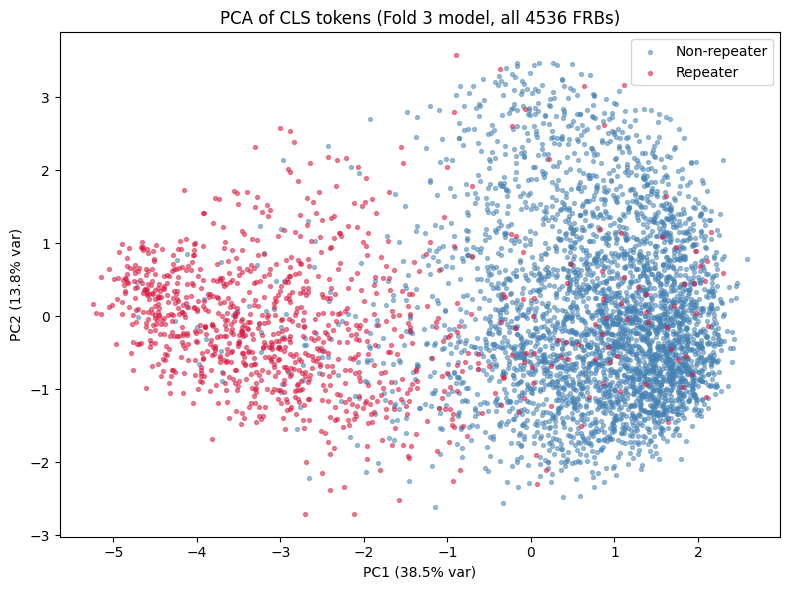

Saved plot -> /scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq/cls_plots/cls_pca_fold3.png


<Figure size 640x480 with 0 Axes>

In [28]:
dataset = CHIMEFRBDataset(HDF5_PATH, CATALOG_PATH, TARGET_LENGTH)
n_total = len(dataset)
n_rep = int(dataset.labels.sum())
print(f"Dataset: {n_total} | repeaters: {n_rep} ({100 * n_rep / n_total:.1f}%)")

model = build_model()
ckpt_path = os.path.join(CHECKPOINT_DIR, f"fold_{FOLD_IDX}.pt")
print(f"Loading checkpoint: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

all_cls = []
all_labels = []

with torch.no_grad():
    for wfall, labels in loader:
        wfall = wfall.to(device)
        x_t = wfall
        x_enc, _, _ = model.encoder(x_t, shared_noise=None, mask_input=False)
        cls_token = x_enc[:, 0, :]  # [B, embed_dim]
        all_cls.append(cls_token.cpu().numpy())
        all_labels.append(labels.numpy())

all_cls = np.concatenate(all_cls, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Extracted CLS tokens: {all_cls.shape}")

np.save(os.path.join(OUTPUT_DIR, f"cls_tokens_fold{FOLD_IDX}.npy"), all_cls)
np.save(os.path.join(OUTPUT_DIR, f"labels_fold{FOLD_IDX}.npy"), all_labels)

# ---- PCA ----
pca = PCA(n_components=2)
cls_2d = pca.fit_transform(all_cls)
var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
plt.scatter(cls_2d[all_labels == 0, 0], cls_2d[all_labels == 0, 1],
            s=8, alpha=0.5, label="Non-repeater", color="steelblue")
plt.scatter(cls_2d[all_labels == 1, 0], cls_2d[all_labels == 1, 1],
            s=8, alpha=0.5, label="Repeater", color="crimson")
plt.xlabel(f"PC1 ({var_ratio[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({var_ratio[1] * 100:.1f}% var)")
plt.title(f"PCA of CLS tokens (Fold {FOLD_IDX} model, all {n_total} FRBs)")
plt.legend()
plt.tight_layout()
plt.show()

out_png = os.path.join(OUTPUT_DIR, f"cls_pca_fold{FOLD_IDX}.png")
plt.savefig(out_png, dpi=200)
print(f"Saved plot -> {out_png}")



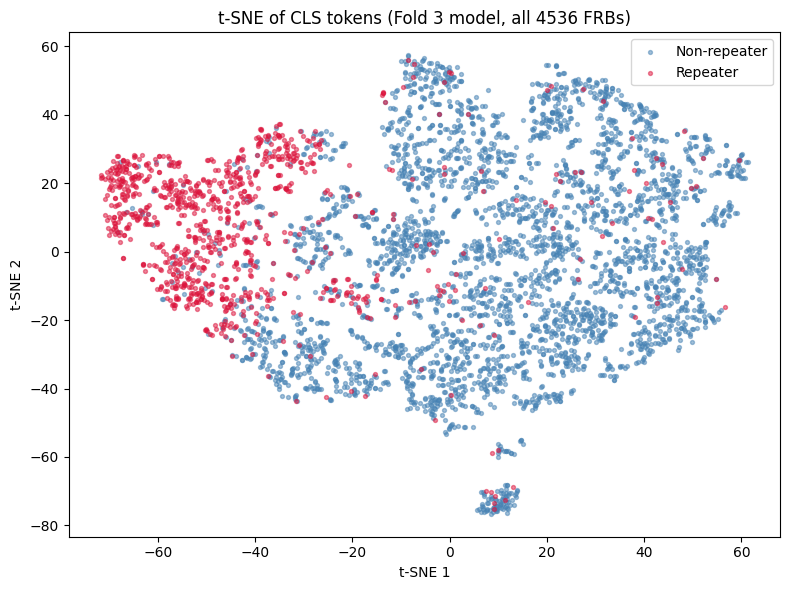

Saved plot -> /scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq/cls_plots/cls_tsne_fold3.png


<Figure size 640x480 with 0 Axes>

In [29]:
# ---- t-SNE ----
tsne = TSNE(n_components=2, random_state=SEED)
tsne_emb = tsne.fit_transform(all_cls)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_emb[all_labels == 0, 0], tsne_emb[all_labels == 0, 1],
            s=8, alpha=0.5, label="Non-repeater", color="steelblue")
plt.scatter(tsne_emb[all_labels == 1, 0], tsne_emb[all_labels == 1, 1],
            s=8, alpha=0.5, label="Repeater", color="crimson")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE of CLS tokens (Fold {FOLD_IDX} model, all {n_total} FRBs)")
plt.legend()
plt.tight_layout()
plt.show()

out_png = os.path.join(OUTPUT_DIR, f"cls_tsne_fold{FOLD_IDX}.png")
plt.savefig(out_png, dpi=200)
print(f"Saved plot -> {out_png}")

-1    2067
 1    1583
 2     798
 0      88
Name: count, dtype: int64


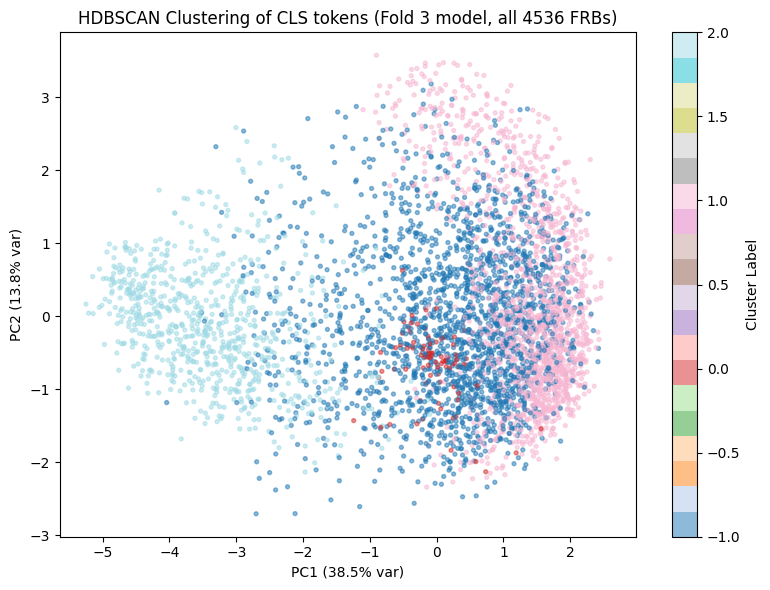

In [ ]:
# Run HDBSCAN clustering on the CLS tokens and then visualize the clusters using PCA and t-SNE.

from hdbscan import HDBSCAN
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import pairwise_distances



scaler = StandardScaler()
all_cls_std = scaler.fit_transform(all_cls)

pca_pre = PCA(n_components=10, random_state=SEED)
all_cls_reduced = pca_pre.fit_transform(all_cls_std)


cos_dist = pairwise_distances(all_cls_reduced, metric='cosine')
hdb = HDBSCAN(min_cluster_size=10, min_samples=5, metric='precomputed')
cluster_labels = hdb.fit_predict(cos_dist.astype(np.float64))




counts = pd.Series(cluster_labels).value_counts()
print(counts)

plt.figure(figsize=(8, 6))
plt.scatter(cls_2d[:, 0], cls_2d[:, 1], c=cluster_labels, cmap='tab20', s=8, alpha=0.5)
plt.xlabel(f"PC1 ({var_ratio[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({var_ratio[1] * 100:.1f}% var)")
plt.title(f"HDBSCAN Clustering of CLS tokens (Fold {FOLD_IDX} model, all {n_total} FRBs)")
plt.colorbar(label='Cluster Label')
plt.tight_layout()

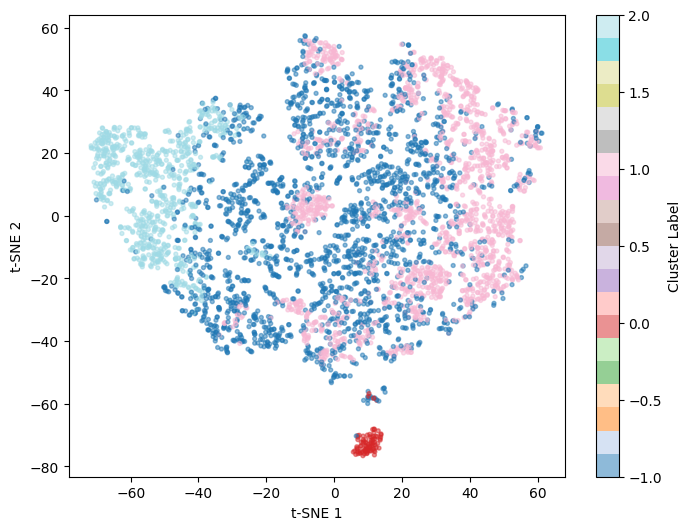

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=cluster_labels, cmap='tab20', s=8, alpha=0.5)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label='Cluster Label')

In [32]:
import pandas as pd

ct = pd.crosstab(cluster_labels, all_labels, rownames=['cluster'], colnames=['label'])
print(ct)
print("Fraction repeater per cluster:")
print(ct[1] / ct.sum(axis=1))

label       0    1
cluster           
-1       1839  228
 0         81    7
 1       1548   35
 2         87  711
Fraction repeater per cluster:
cluster
-1    0.110305
 0    0.079545
 1    0.022110
 2    0.890977
dtype: float64


In [33]:
# Treating "in cluster 2" as a repeater prediction
pred_repeater = (cluster_labels == 2).astype(int)
from sklearn.metrics import confusion_matrix, f1_score
print(confusion_matrix(all_labels, pred_repeater))
print("F1:", f1_score(all_labels, pred_repeater))

[[3468   87]
 [ 270  711]]
F1: 0.7993254637436762


In [ ]:
def register_attention_hooks(model):
    attention_maps = {}
    handles = []

    def pre_hook(module, args, kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        return args, kwargs

    def make_post_hook(name):
        def post_hook(module, input, output):
            # output = (attn_output, attn_weights) when need_weights=True
            _, attn_weights = output
            attention_maps[name] = attn_weights.detach().cpu()
        return post_hook

    for i, layer in enumerate(model.enc_blocks):
        handles.append(layer.self_attn.register_forward_pre_hook(pre_hook, with_kwargs=True))
        handles.append(layer.self_attn.register_forward_hook(make_post_hook(f"enc_{i}")))

    for i, layer in enumerate(model.dec_blocks):
        handles.append(layer.self_attn.register_forward_pre_hook(pre_hook, with_kwargs=True))
        handles.append(layer.self_attn.register_forward_hook(make_post_hook(f"dec_{i}")))

    return attention_maps, handles

In [ ]:
model.eval()
attention_maps, handles = register_attention_hooks(model)

In [ ]:
with torch.no_grad():
    wfall, labels = next(iter(loader))
    wfall = wfall.to(device)
    x_t = wfall  # [B, F, T]
    x_enc, _, _ = model.encoder(x_t, shared_noise=None, mask_input=False)

print({k: v.shape for k, v in attention_maps.items()})

In [ ]:
def get_ordered_encoder_attentions(attention_maps):
    enc_keys = sorted(
        [k for k in attention_maps if k.startswith("enc_")],
        key=lambda k: int(k.split("_")[1])
    )
    return [attention_maps[k] for k in enc_keys]

def attention_rollout(attentions):
    B, _, N, _ = attentions[0].shape
    rollout = torch.eye(N).unsqueeze(0).repeat(B, 1, 1)

    for attention in attentions:
        fused = attention.mean(dim=1)                              
        fused = fused + torch.eye(N).unsqueeze(0)                   
        fused = fused / fused.sum(dim=-1, keepdim=True)           
        rollout = torch.bmm(rollout, fused)               

    return rollout  # (B, N, N)

ordered_attns = get_ordered_encoder_attentions(attention_maps)
rollout = attention_rollout(ordered_attns)

sample_idx = 1
cls_attn = rollout[sample_idx, 0, 1:]          
cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8) #minmax scaling

wfall_sample = wfall[sample_idx].cpu().numpy()
attn_map_2d = cls_attn.numpy()[:, None] * np.ones((1, wfall_sample.shape[1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wfall_sample, aspect="auto", cmap="viridis")
axes[0].set_title(f"Waterfall (label={labels[sample_idx].item()})")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Frequency channel")

axes[1].imshow(wfall_sample, aspect="auto", cmap="gray")
axes[1].imshow(attn_map_2d, aspect="auto", cmap="hot", alpha=0.7)
axes[1].set_title("Rollout attention (CLS -> freq channel), broadcast over time")
axes[1].set_xlabel("Time bin")
axes[1].set_ylabel("Frequency channel")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "attention_rollout_sample0.png"), dpi=150)
plt.show()

In [ ]:
loader_full = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

sum_attn = {-1: None, 0: None, 1: None, 2: None}
count = {-1: 0, 0: 0, 1: 0, 2: 0}

model.eval()
idx = 0
with torch.no_grad():
    for wfall, _ in loader_full:
        b = wfall.size(0)
        batch_clusters = cluster_labels[idx: idx + b]
        idx += b
        wfall = wfall.to(device)
        attention_maps.clear()
        x_enc, _, _ = model.encoder(wfall, shared_noise=None, mask_input=False)

        ordered_attns = get_ordered_encoder_attentions(attention_maps)
        rollout = attention_rollout(ordered_attns)  # (B, N, N)

        cls_attn = rollout[:, 0, 1:]
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)

        for c in [-1, 0, 1, 2]:
            mask = torch.from_numpy(batch_clusters == c)
            if mask.sum() == 0:
                continue
            batch_sum = cls_attn[mask].sum(dim=0)
            sum_attn[c] = batch_sum if sum_attn[c] is None else sum_attn[c] + batch_sum
            count[c] += mask.sum().item()

mean_attn = {c: (sum_attn[c] / count[c]).numpy() for c in [-1, 0, 1, 2] if count[c] > 0}

n_clusters = len(mean_attn)
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), sharey=True)
if n_clusters == 1:
    axes = [axes]

for ax, c in zip(axes, sorted(mean_attn.keys())):
    ax.plot(mean_attn[c])
    ax.set_title(f"Cluster {c} (n={count[c]})")
    ax.set_xlabel("Frequency channel")
axes[0].set_ylabel("Mean CLS attention (rollout)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_rollout_maps.png"), dpi=150)
plt.show()